# Cool Data Visualizations: Book Adaptations Analysis

This notebook contains advanced visualizations exploring the relationship between books and their movie adaptations.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('final_data.csv')

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (3265, 13)

Columns: ['Unnamed: 0', 'movie_title', 'movie_budget', 'movie_revenue', 'movie_release', 'imdb_total_votes', 'Publisher', 'Pages', 'RatingDistTotal', 'Authors', 'Book Rating', 'Movie Rating', 'movie_profit']


,Unnamed: 0,movie_title,movie_budget,movie_revenue,movie_release,imdb_total_votes,Publisher,Pages,RatingDistTotal,Authors,Book Rating,Movie Rating,movie_profit
0,0,Jumanji,1.400925e+08,5.663988e+08,1995.0,404354.0,Scholastic,48.0,28,A.L. Singer,0.814,0.71,4.263063e+08
1,1,Heat,1.293161e+08,4.039768e+08,1995.0,779065.0,Philomel Books,220.0,19350,Mike Lupica,0.796,0.83,2.746606e+08
2,2,Heat,1.293161e+08,4.039768e+08,1995.0,779065.0,iUniverse,256.0,73,Arthur Herzog III,0.690,0.83,2.746606e+08
3,3,Sense and Sensibility,3.556194e+07,2.909613e+08,1995.0,134114.0,"Oxford University Press, USA",446.0,917623,Jane Austen,0.814,0.77,2.553994e+08
4,4,Sense and Sensibility,3.556194e+07,2.909613e+08,1995.0,134114.0,AudioGO,NaN,917839,Jane Austen,0.814,0.77,2.553994e+08


## 1. Four-Quadrant Analysis: Winners and Losers

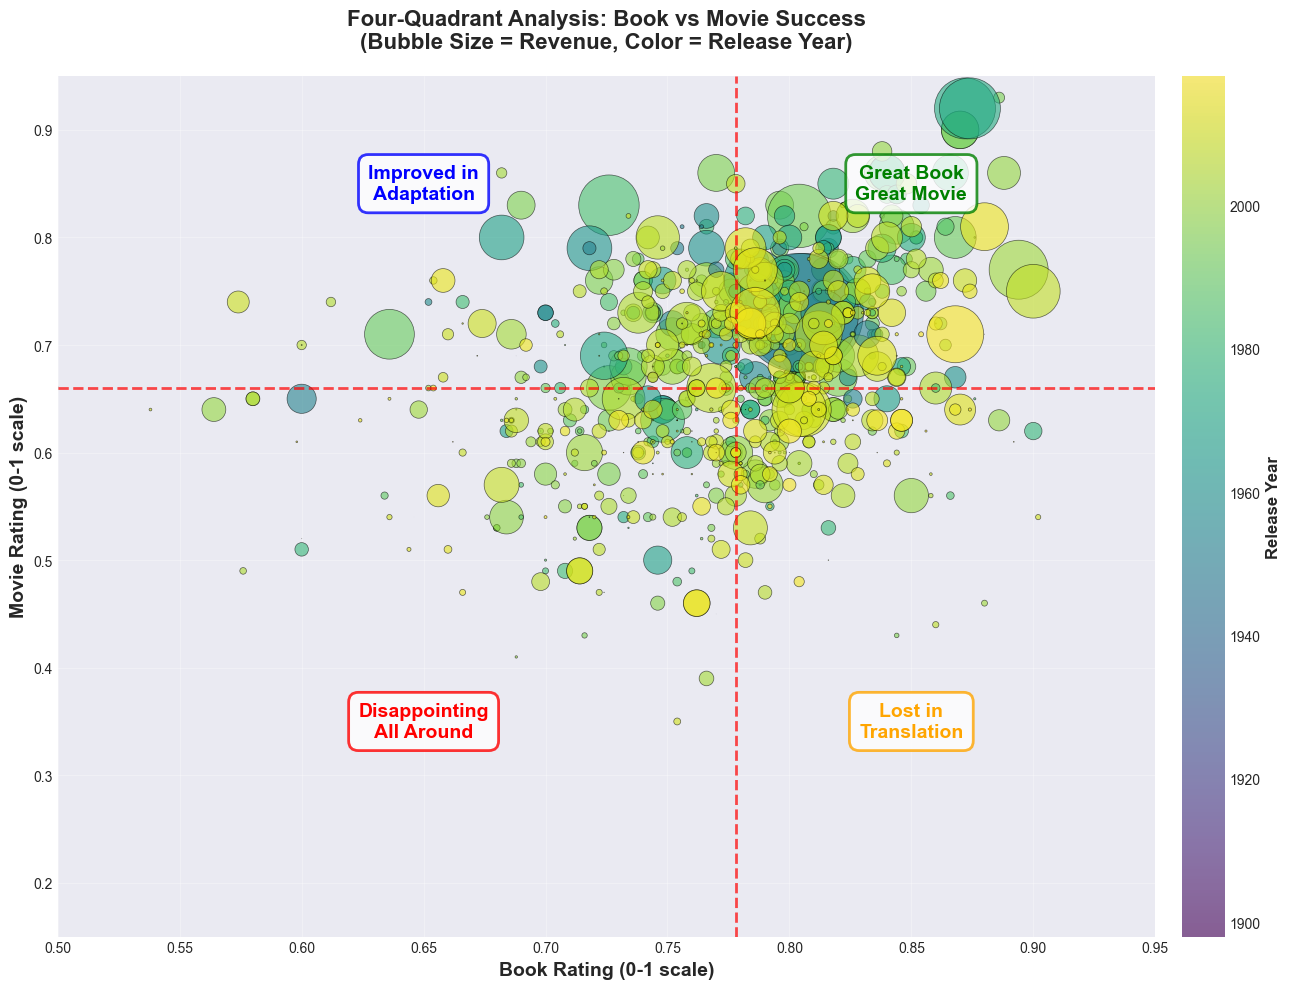

In [11]:
fig, ax = plt.subplots(figsize=(14, 10))

# Calculate medians
book_median = df['Book Rating'].median()
movie_median = df['Movie Rating'].median()

# Create scatter plot with size based on revenue
scatter = ax.scatter(df['Book Rating'], 
                    df['Movie Rating'],
                    s=df['movie_revenue'] / 1e6,  # Size by revenue (millions)
                    c=df['movie_release'],  # Color by year
                    cmap='viridis',
                    alpha=0.6,
                    edgecolors='black',
                    linewidth=0.5)

# Add quadrant lines
ax.axhline(y=movie_median, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.axvline(x=book_median, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Label quadrants
quadrant_labels = [
    (0.85, 0.85, 'Great Book\nGreat Movie', 'green'),
    (0.65, 0.85, 'Improved in\nAdaptation', 'blue'),
    (0.65, 0.35, 'Disappointing\nAll Around', 'red'),
    (0.85, 0.35, 'Lost in\nTranslation', 'orange')
]

for x, y, text, color in quadrant_labels:
    ax.text(x, y, text, fontsize=14, fontweight='bold', 
            ha='center', va='center', color=color,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor=color, linewidth=2))

# Formatting
ax.set_xlabel('Book Rating (0-1 scale)', fontsize=14, fontweight='bold')
ax.set_ylabel('Movie Rating (0-1 scale)', fontsize=14, fontweight='bold')
ax.set_title('Four-Quadrant Analysis: Book vs Movie Success\n(Bubble Size = Revenue, Color = Release Year)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, 0.95)
ax.set_ylim(0.15, 0.95)

# Add colorbars
cb = plt.colorbar(scatter, ax=ax, pad=0.02)
cb.set_label('Release Year', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_quadrant_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Revenue vs Ratings: 3D Bubble Chart Effect

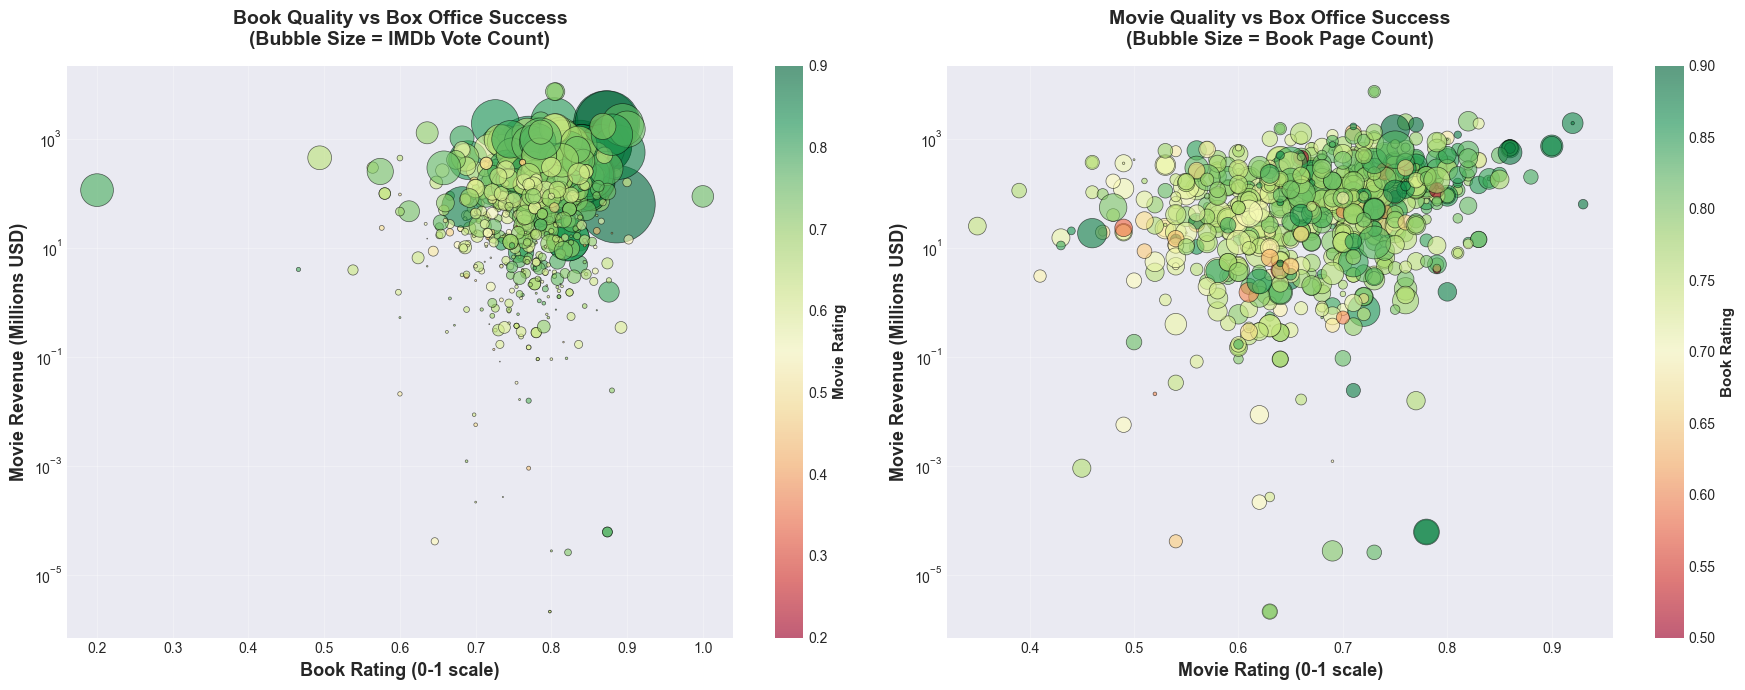

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left plot: Book Rating vs Revenue
mask = (df['Book Rating'].notna()) & (df['movie_revenue'] > 0)
scatter1 = ax1.scatter(df.loc[mask, 'Book Rating'], 
                       df.loc[mask, 'movie_revenue'] / 1e6,
                       s=df.loc[mask, 'imdb_total_votes'] / 1000,  # Size by vote count
                       c=df.loc[mask, 'Movie Rating'],
                       cmap='RdYlGn',
                       alpha=0.6,
                       edgecolors='black',
                       linewidth=0.5,
                       vmin=0.2, vmax=0.9)

ax1.set_xlabel('Book Rating (0-1 scale)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Movie Revenue (Millions USD)', fontsize=13, fontweight='bold')
ax1.set_title('Book Quality vs Box Office Success\n(Bubble Size = IMDb Vote Count)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
cb1 = plt.colorbar(scatter1, ax=ax1)
cb1.set_label('Movie Rating', fontsize=11, fontweight='bold')

# Right plot: Movie Rating vs Revenue
mask2 = (df['Movie Rating'].notna()) & (df['movie_revenue'] > 0)
scatter2 = ax2.scatter(df.loc[mask2, 'Movie Rating'], 
                       df.loc[mask2, 'movie_revenue'] / 1e6,
                       s=df.loc[mask2, 'Pages'].fillna(0) / 2,  # Size by book length
                       c=df.loc[mask2, 'Book Rating'],
                       cmap='RdYlGn',
                       alpha=0.6,
                       edgecolors='black',
                       linewidth=0.5,
                       vmin=0.5, vmax=0.9)

ax2.set_xlabel('Movie Rating (0-1 scale)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Movie Revenue (Millions USD)', fontsize=13, fontweight='bold')
ax2.set_title('Movie Quality vs Box Office Success\n(Bubble Size = Book Page Count)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
cb2 = plt.colorbar(scatter2, ax=ax2)
cb2.set_label('Book Rating', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_revenue_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Time Series: Evolution of Adaptations Over Decades

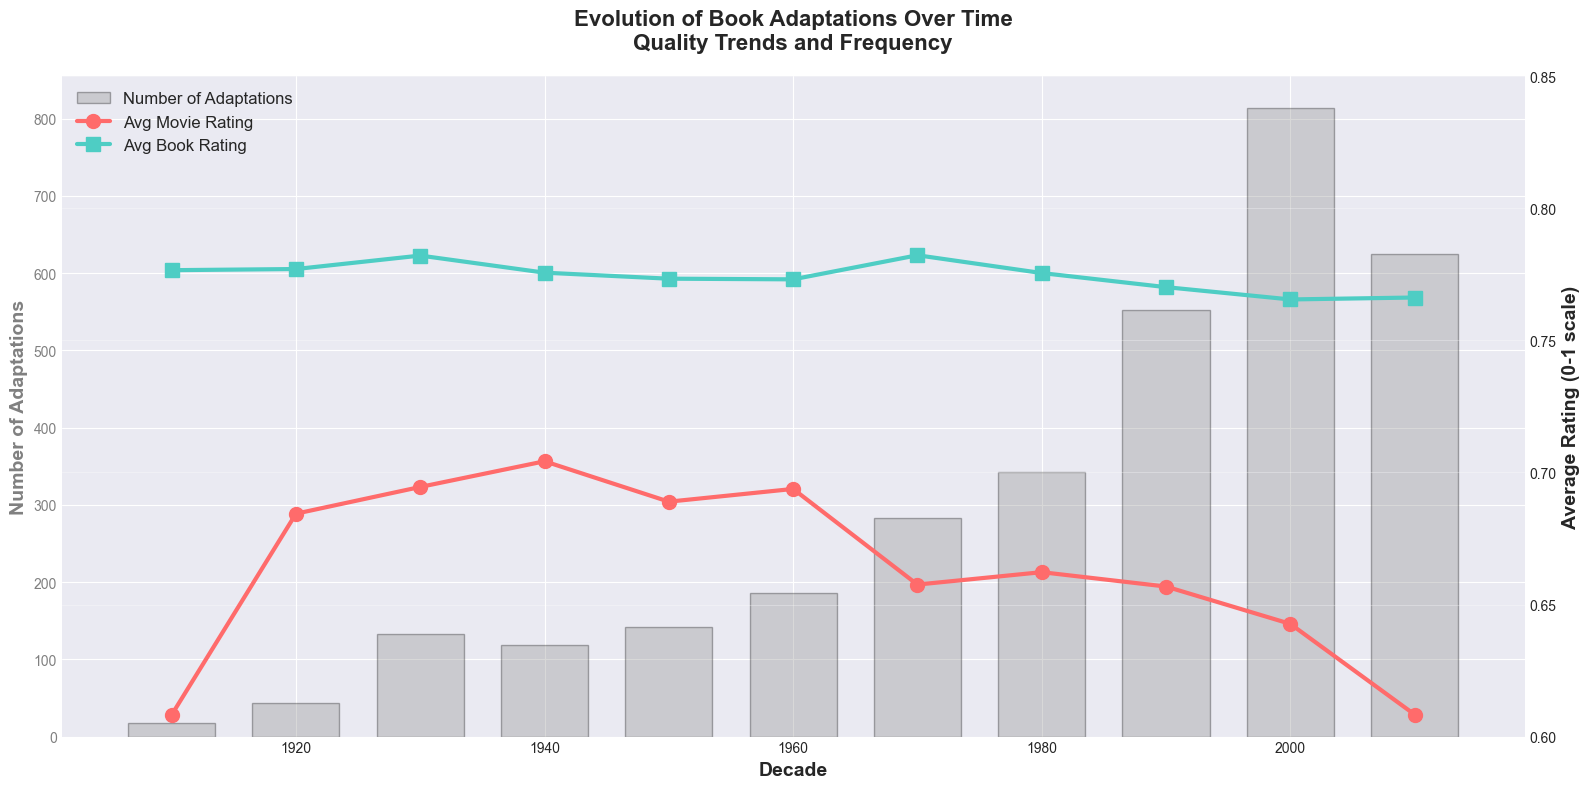

In [13]:
# Create decade bins
df['decade'] = (df['movie_release'] // 10 * 10).astype('Int64')

# Calculate statistics by decade
decade_stats = df.groupby('decade').agg({
    'Movie Rating': 'mean',
    'Book Rating': 'mean',
    'movie_revenue': 'median',
    'movie_title': 'count'
}).reset_index()
decade_stats.columns = ['decade', 'avg_movie_rating', 'avg_book_rating', 'median_revenue', 'num_adaptations']

# Filter to decades with sufficient data
decade_stats = decade_stats[decade_stats['num_adaptations'] >= 10]

# Create figure with dual axes
fig, ax1 = plt.subplots(figsize=(16, 8))

# Bar chart for number of adaptations
ax1.bar(decade_stats['decade'], decade_stats['num_adaptations'], 
        width=7, alpha=0.3, color='gray', label='Number of Adaptations', edgecolor='black')
ax1.set_xlabel('Decade', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Adaptations', fontsize=14, fontweight='bold', color='gray')
ax1.tick_params(axis='y', labelcolor='gray')

# Create second y-axis for ratings
ax2 = ax1.twinx()
ax2.plot(decade_stats['decade'], decade_stats['avg_movie_rating'], 
         marker='o', linewidth=3, markersize=10, label='Avg Movie Rating', color='#FF6B6B')
ax2.plot(decade_stats['decade'], decade_stats['avg_book_rating'], 
         marker='s', linewidth=3, markersize=10, label='Avg Book Rating', color='#4ECDC4')
ax2.set_ylabel('Average Rating (0-1 scale)', fontsize=14, fontweight='bold')
ax2.set_ylim(0.6, 0.85)
ax2.grid(True, alpha=0.3, axis='y')

# Title and legends
ax1.set_title('Evolution of Book Adaptations Over Time\nQuality Trends and Frequency', 
              fontsize=16, fontweight='bold', pad=20)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12, framealpha=0.9)

plt.tight_layout()
plt.savefig('viz_time_series.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Heatmap: Correlation Matrix

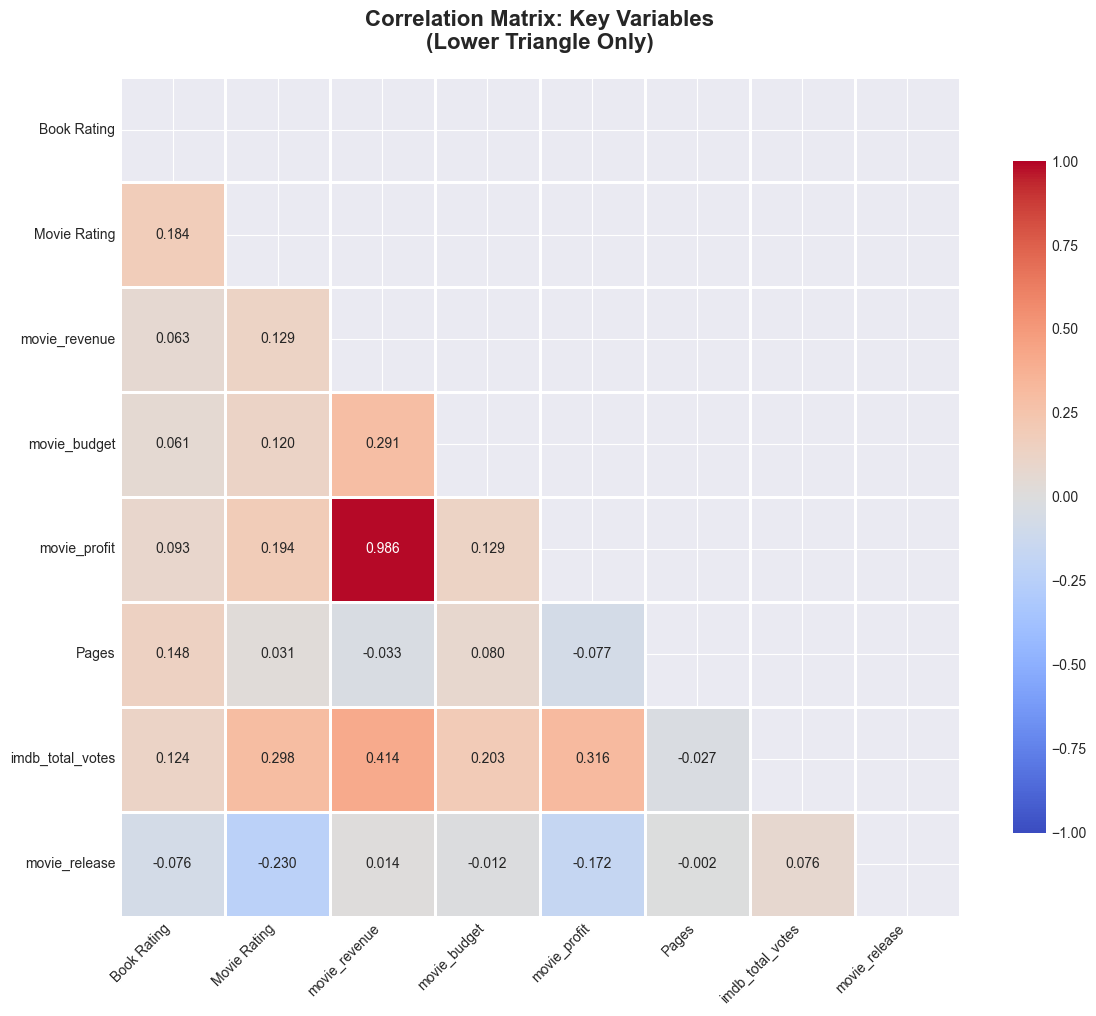


Key Correlations:
Book Rating vs Movie Rating: 0.1840
Movie Budget vs Revenue: 0.2906
IMDb Votes vs Revenue: 0.4136


In [14]:
# Select numeric columns for correlation
numeric_cols = ['Book Rating', 'Movie Rating', 'movie_revenue', 'movie_budget', 
                'movie_profit', 'Pages', 'imdb_total_votes', 'movie_release']
corr_data = df[numeric_cols].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_data, dtype=bool))

sns.heatmap(corr_data, mask=mask, annot=True, fmt='.3f', 
            cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Matrix: Key Variables\n(Lower Triangle Only)', 
             fontsize=16, fontweight='bold', pad=20)

# Rotate labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('viz_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print interesting correlations
print("\nKey Correlations:")
print(f"Book Rating vs Movie Rating: {corr_data.loc['Book Rating', 'Movie Rating']:.4f}")
print(f"Movie Budget vs Revenue: {corr_data.loc['movie_budget', 'movie_revenue']:.4f}")
print(f"IMDb Votes vs Revenue: {corr_data.loc['imdb_total_votes', 'movie_revenue']:.4f}")

## 5. Ridge Plot: Rating Distributions by Decade

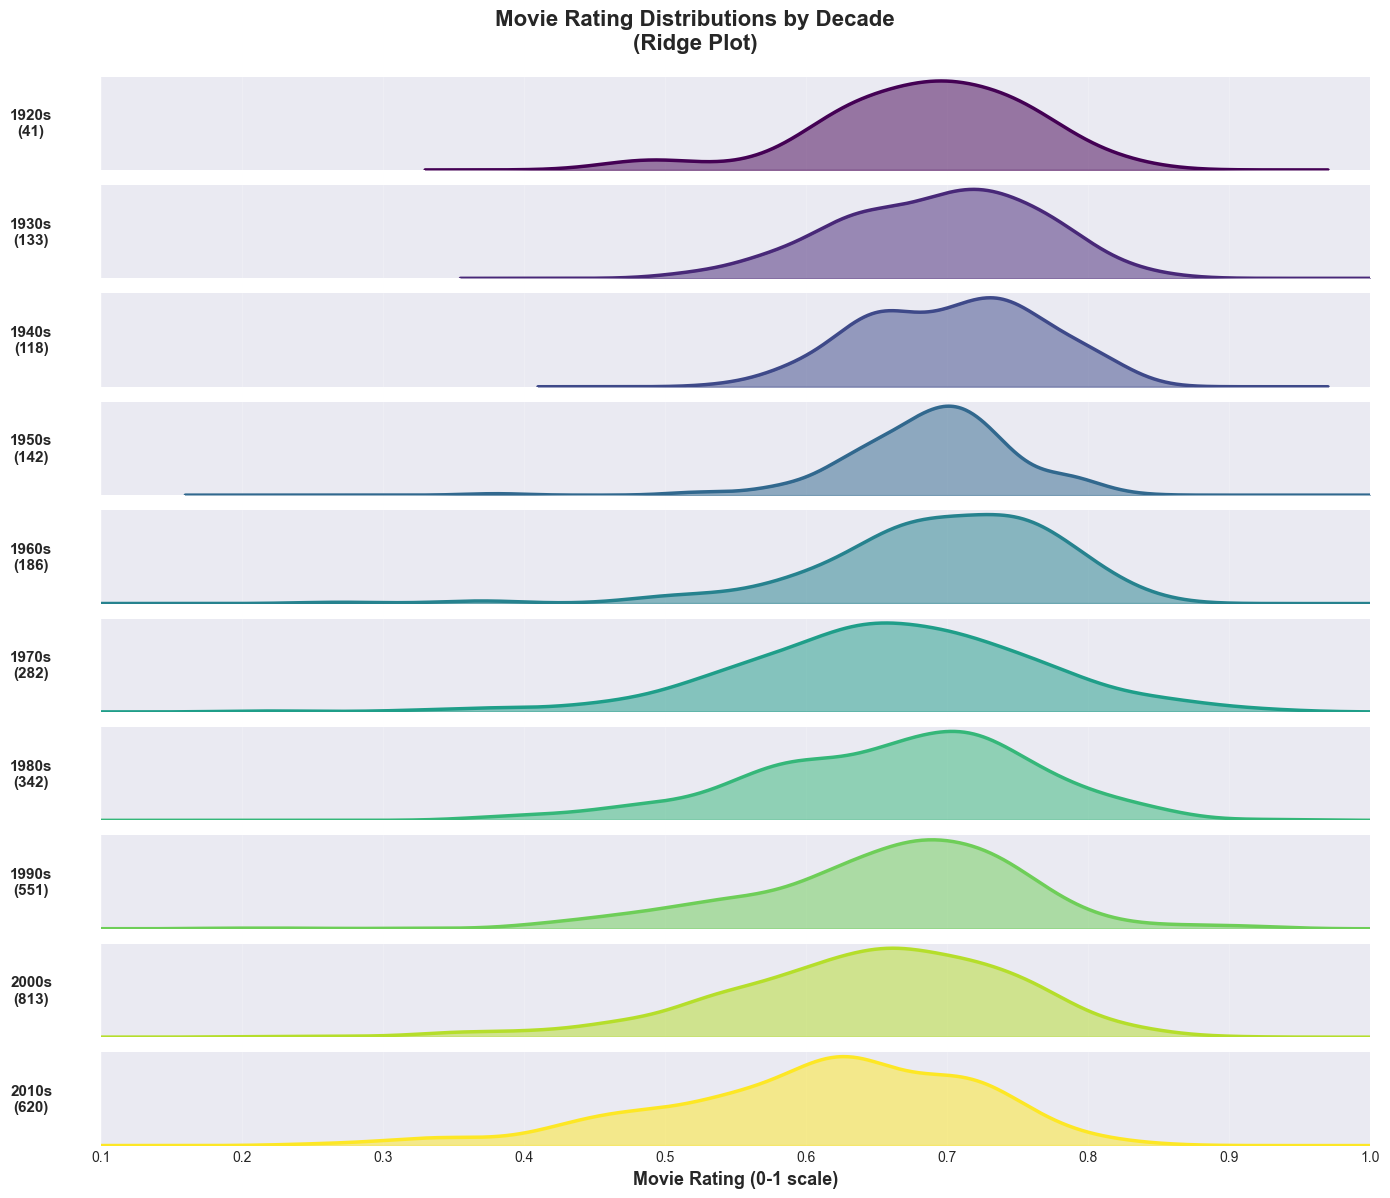

In [15]:
from matplotlib.patches import Polygon

# Prepare data
decades_to_plot = df[df['decade'].notna() & (df['Movie Rating'].notna())].copy()
decades_list = sorted(decades_to_plot['decade'].unique())

# Filter to decades with enough data
decade_counts = decades_to_plot['decade'].value_counts()
decades_list = [d for d in decades_list if decade_counts[d] >= 20]

# Create figure
fig, axes = plt.subplots(len(decades_list), 1, figsize=(14, len(decades_list) * 1.2), 
                        sharex=True)

if len(decades_list) == 1:
    axes = [axes]

colors = plt.cm.viridis(np.linspace(0, 1, len(decades_list)))

for idx, (decade, ax) in enumerate(zip(decades_list, axes)):
    decade_data = decades_to_plot[decades_to_plot['decade'] == decade]['Movie Rating'].dropna()
    
    # Create density plot
    density = decade_data.plot.density(ax=ax, color=colors[idx], linewidth=2.5)
    
    # Fill under the curve
    line = density.get_lines()[0]
    x, y = line.get_data()
    ax.fill_between(x, 0, y, alpha=0.5, color=colors[idx])
    
    # Formatting
    ax.set_ylabel(f"{int(decade)}s\n({len(decade_data)})", 
                 fontsize=11, fontweight='bold', rotation=0, labelpad=50, va='center')
    ax.set_xlim(0.1, 1.0)
    ax.set_ylim(0, None)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.grid(True, alpha=0.2, axis='x')

axes[-1].set_xlabel('Movie Rating (0-1 scale)', fontsize=13, fontweight='bold')
fig.suptitle('Movie Rating Distributions by Decade\n(Ridge Plot)', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('viz_ridge_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Top Authors Analysis

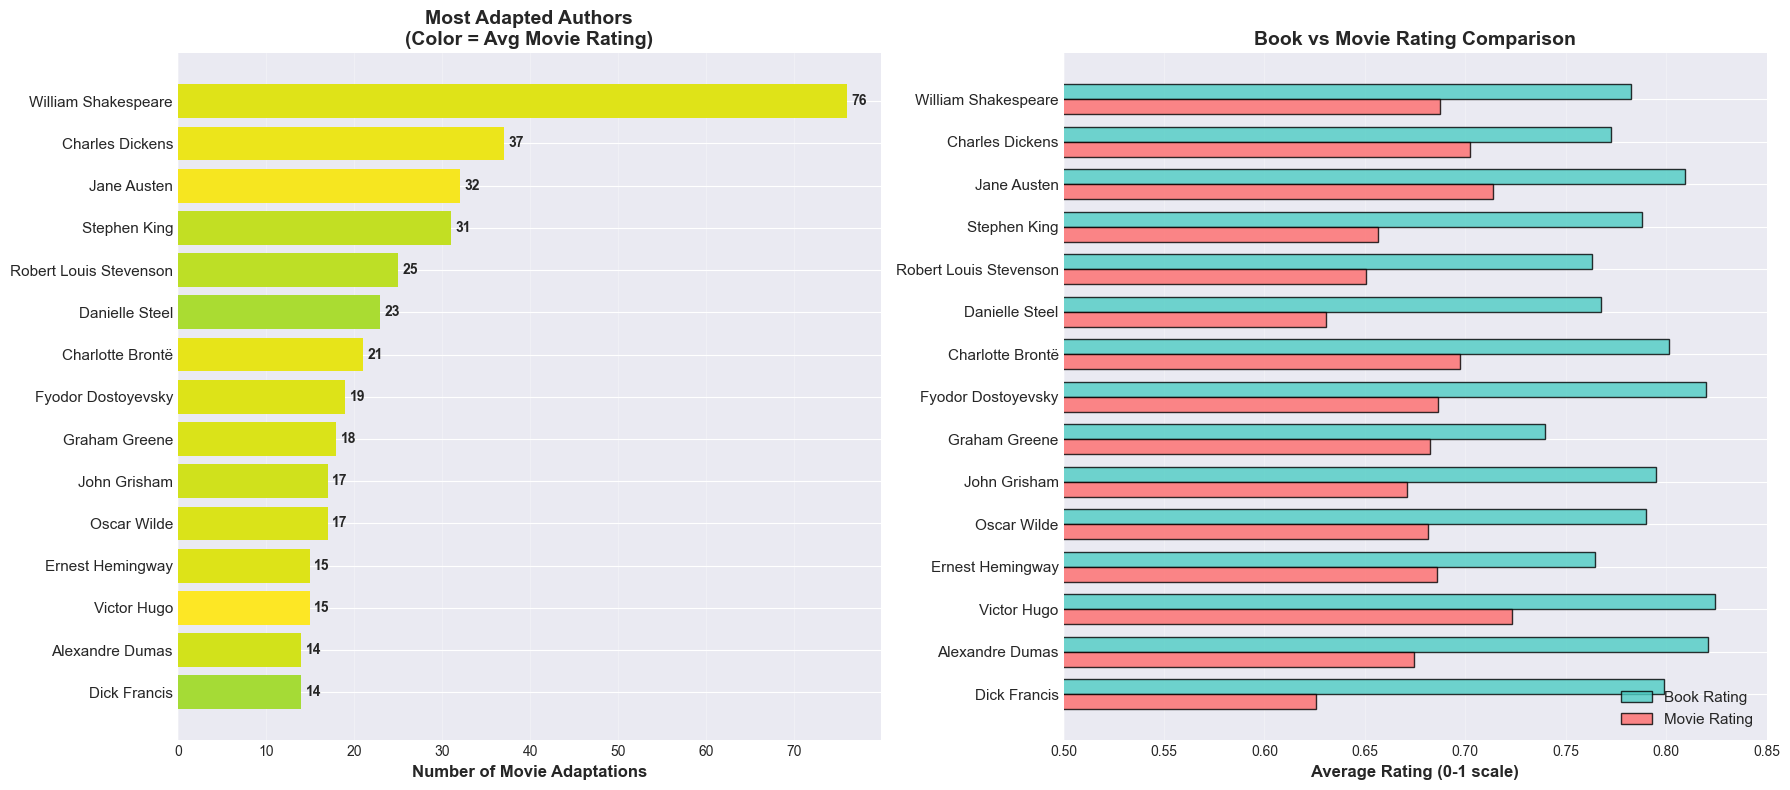


Top 5 Most Adapted Authors:
                      Author  Num_Adaptations  Avg_Movie_Rating  \
1290     William Shakespeare               76          0.687500   
181          Charles Dickens               37          0.702432   
568              Jane Austen               32          0.713750   
1169            Stephen King               31          0.656774   
1068  Robert Louis Stevenson               25          0.650400   

      Avg_Book_Rating  
1290         0.782684  
181          0.772432  
568          0.809625  
1169         0.788000  
1068         0.763280  


In [16]:
# Find authors with most adaptations
author_stats = df.groupby('Authors').agg({
    'movie_title': 'count',
    'Movie Rating': 'mean',
    'Book Rating': 'mean',
    'movie_revenue': 'sum'
}).reset_index()
author_stats.columns = ['Author', 'Num_Adaptations', 'Avg_Movie_Rating', 'Avg_Book_Rating', 'Total_Revenue']

# Get top 15 authors by number of adaptations
top_authors = author_stats.nlargest(15, 'Num_Adaptations')

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left plot: Number of adaptations
y_pos = np.arange(len(top_authors))
bars1 = ax1.barh(y_pos, top_authors['Num_Adaptations'], 
                 color=plt.cm.viridis(top_authors['Avg_Movie_Rating'] / top_authors['Avg_Movie_Rating'].max()))
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_authors['Author'], fontsize=11)
ax1.invert_yaxis()
ax1.set_xlabel('Number of Movie Adaptations', fontsize=12, fontweight='bold')
ax1.set_title('Most Adapted Authors\n(Color = Avg Movie Rating)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(top_authors['Num_Adaptations']):
    ax1.text(v + 0.5, i, str(int(v)), va='center', fontweight='bold')

# Right plot: Rating comparison
x = np.arange(len(top_authors))
width = 0.35

bars2 = ax2.barh(x - width/2, top_authors['Avg_Book_Rating'], width, 
                 label='Book Rating', color='#4ECDC4', alpha=0.8, edgecolor='black')
bars3 = ax2.barh(x + width/2, top_authors['Avg_Movie_Rating'], width, 
                 label='Movie Rating', color='#FF6B6B', alpha=0.8, edgecolor='black')

ax2.set_yticks(x)
ax2.set_yticklabels(top_authors['Author'], fontsize=11)
ax2.invert_yaxis()
ax2.set_xlabel('Average Rating (0-1 scale)', fontsize=12, fontweight='bold')
ax2.set_title('Book vs Movie Rating Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_xlim(0.5, 0.85)

plt.tight_layout()
plt.savefig('viz_top_authors.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 Most Adapted Authors:")
print(top_authors[['Author', 'Num_Adaptations', 'Avg_Movie_Rating', 'Avg_Book_Rating']].head())

## 7. Success/Failure Analysis: Biggest Winners and Losers

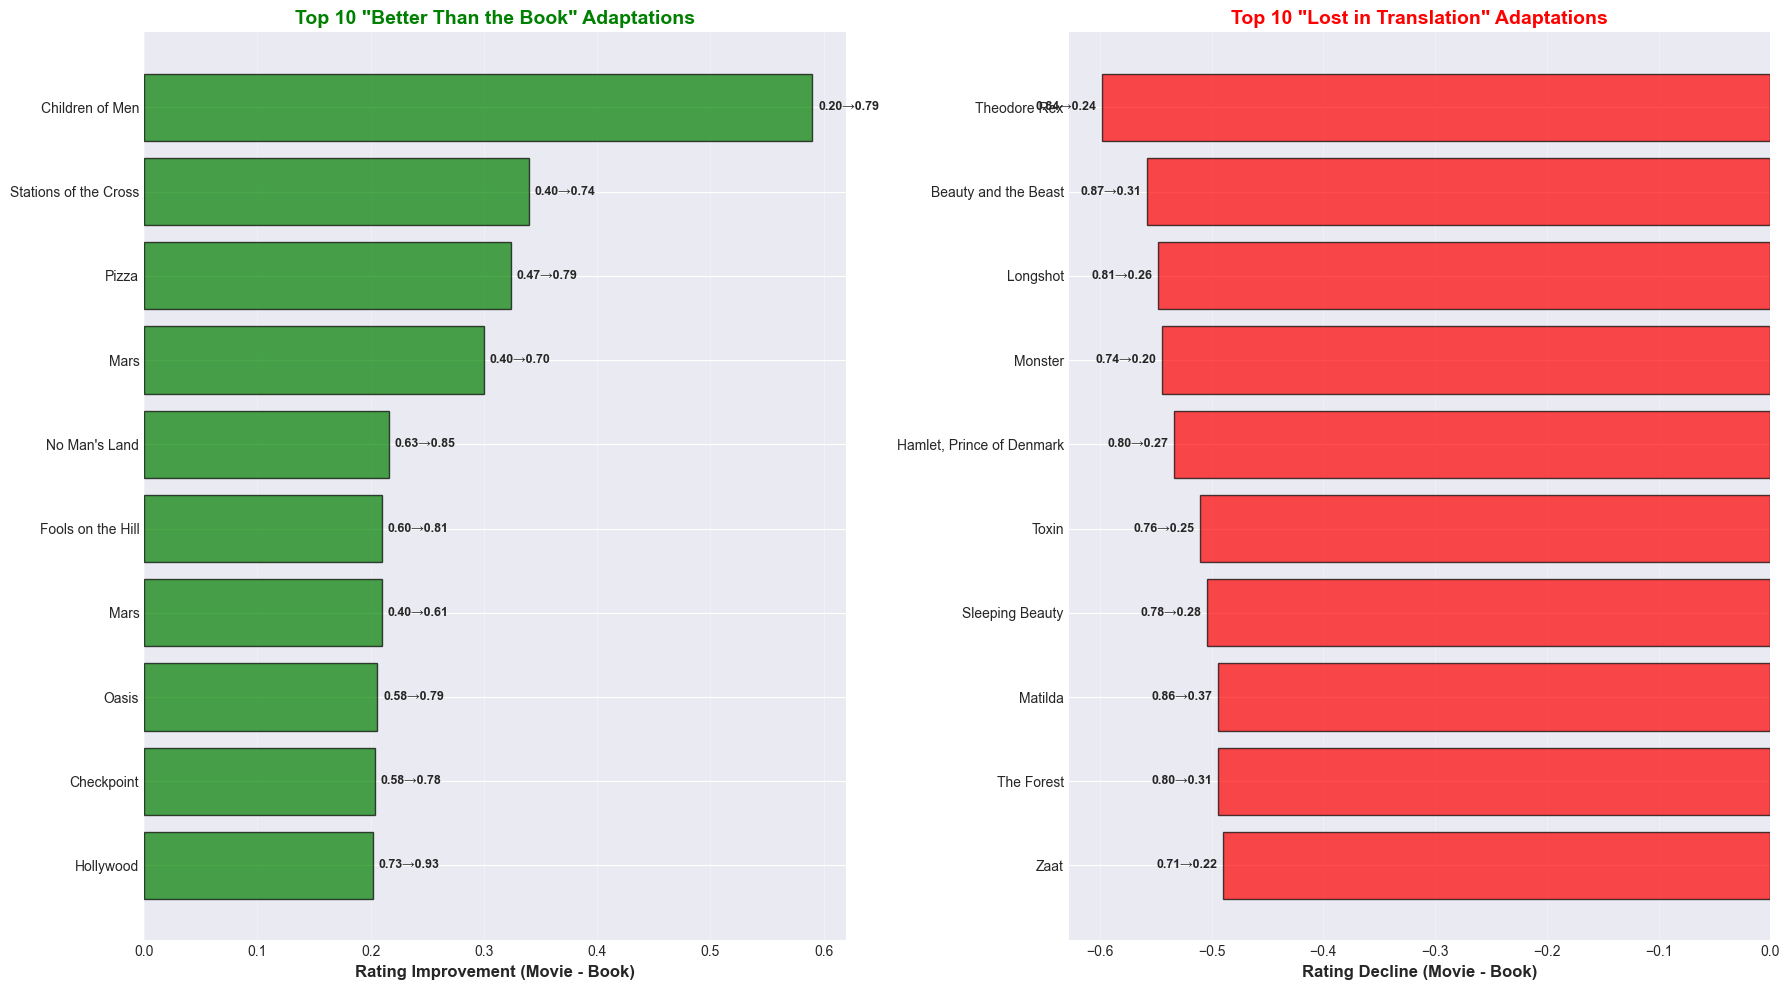

In [17]:
# Calculate rating difference (movie - book)
df['rating_diff'] = df['Movie Rating'] - df['Book Rating']

# Get extreme cases
biggest_improvements = df.nlargest(10, 'rating_diff')[['movie_title', 'Authors', 'Book Rating', 'Movie Rating', 'rating_diff']]
biggest_disappointments = df.nsmallest(10, 'rating_diff')[['movie_title', 'Authors', 'Book Rating', 'Movie Rating', 'rating_diff']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# Biggest improvements
y_pos = np.arange(len(biggest_improvements))
bars1 = ax1.barh(y_pos, biggest_improvements['rating_diff'], color='green', alpha=0.7, edgecolor='black')
ax1.set_yticks(y_pos)
labels1 = [f"{row['movie_title'][:30]}..." if len(row['movie_title']) > 30 else row['movie_title'] 
           for _, row in biggest_improvements.iterrows()]
ax1.set_yticklabels(labels1, fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('Rating Improvement (Movie - Book)', fontsize=12, fontweight='bold')
ax1.set_title('Top 10 "Better Than the Book" Adaptations', fontsize=14, fontweight='bold', color='green')
ax1.grid(True, alpha=0.3, axis='x')

for i, (v, book_r, movie_r) in enumerate(zip(biggest_improvements['rating_diff'], 
                                              biggest_improvements['Book Rating'],
                                              biggest_improvements['Movie Rating'])):
    ax1.text(v + 0.005, i, f"{book_r:.2f}→{movie_r:.2f}", va='center', fontsize=9, fontweight='bold')

# Biggest disappointments
y_pos = np.arange(len(biggest_disappointments))
bars2 = ax2.barh(y_pos, biggest_disappointments['rating_diff'], color='red', alpha=0.7, edgecolor='black')
ax2.set_yticks(y_pos)
labels2 = [f"{row['movie_title'][:30]}..." if len(row['movie_title']) > 30 else row['movie_title'] 
           for _, row in biggest_disappointments.iterrows()]
ax2.set_yticklabels(labels2, fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('Rating Decline (Movie - Book)', fontsize=12, fontweight='bold')
ax2.set_title('Top 10 "Lost in Translation" Adaptations', fontsize=14, fontweight='bold', color='red')
ax2.grid(True, alpha=0.3, axis='x')

for i, (v, book_r, movie_r) in enumerate(zip(biggest_disappointments['rating_diff'], 
                                              biggest_disappointments['Book Rating'],
                                              biggest_disappointments['Movie Rating'])):
    ax2.text(v - 0.005, i, f"{book_r:.2f}→{movie_r:.2f}", va='center', ha='right', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_winners_losers.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. 2D Density Heatmap: Book Ratings vs Movie Ratings

This heatmap shows the density/frequency of book-movie rating combinations, helping visualize where most adaptations fall in the rating space.

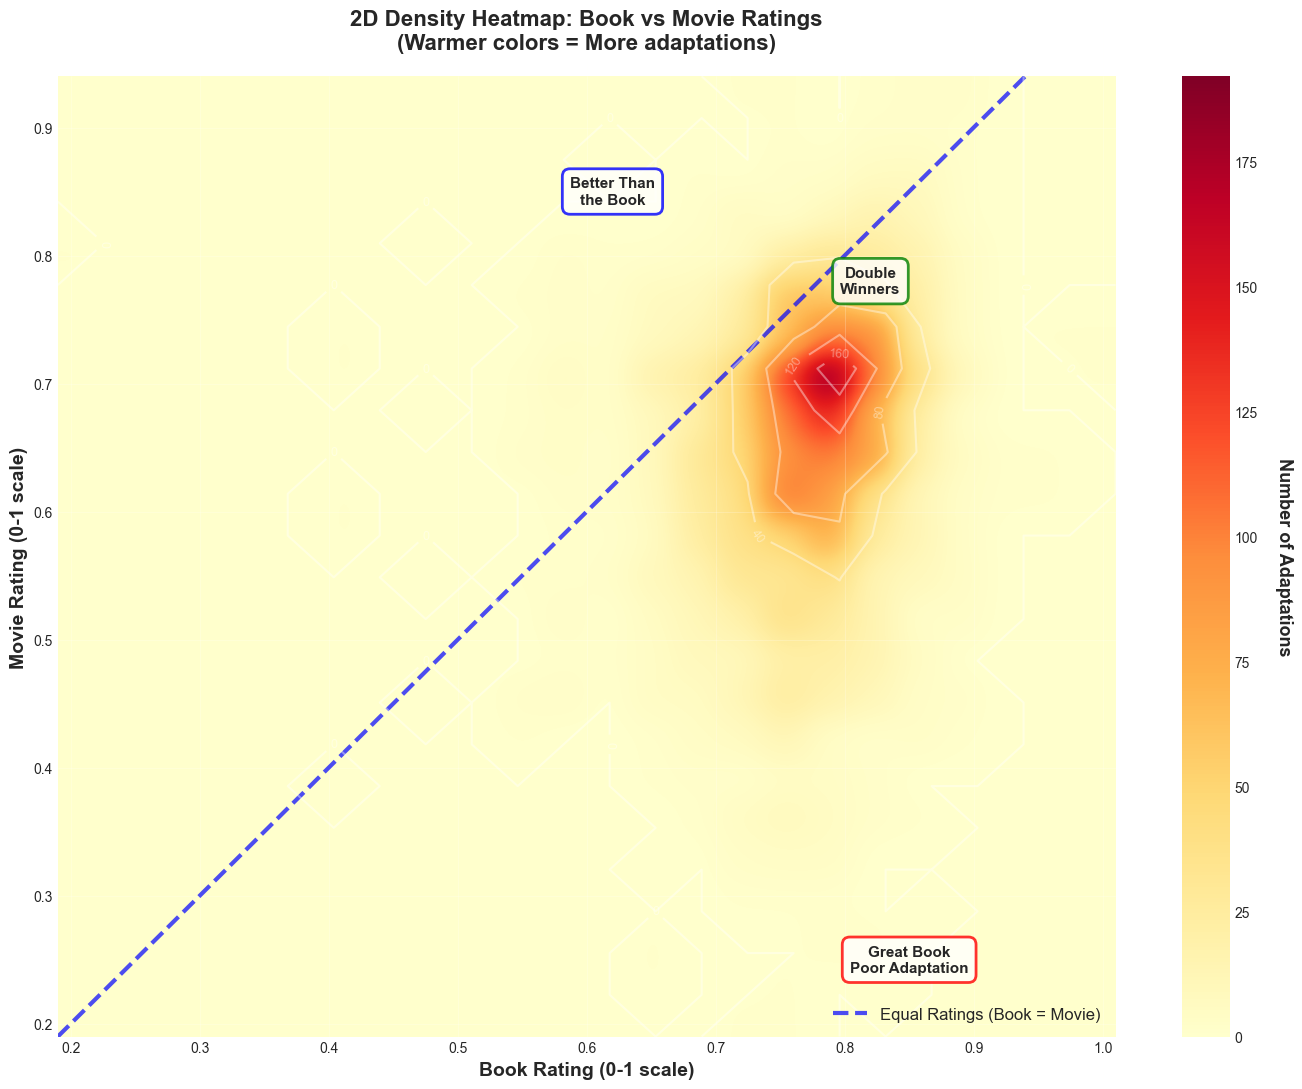


Density Statistics:
Total data points: 3,237

Ratings above diagonal (movie > book): 318 (9.8%)
Ratings below diagonal (book > movie): 2895 (89.4%)
Ratings on diagonal (roughly equal): 646 (20.0%)


In [18]:
# Create a 2D density heatmap showing the distribution of rating combinations
fig, ax = plt.subplots(figsize=(14, 11))

# Remove NaN values
clean_data = df[['Book Rating', 'Movie Rating']].dropna()

# Create bins for the heatmap
book_bins = np.linspace(clean_data['Book Rating'].min() - 0.01, 
                        clean_data['Book Rating'].max() + 0.01, 25)
movie_bins = np.linspace(clean_data['Movie Rating'].min() - 0.01, 
                         clean_data['Movie Rating'].max() + 0.01, 25)

# Create 2D histogram
hist, xedges, yedges = np.histogram2d(clean_data['Book Rating'], 
                                      clean_data['Movie Rating'],
                                      bins=[book_bins, movie_bins])

# Create the heatmap
im = ax.imshow(hist.T, origin='lower', aspect='auto', cmap='YlOrRd',
               extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
               interpolation='gaussian')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of Adaptations', fontsize=13, fontweight='bold', rotation=270, labelpad=25)

# Add diagonal line (where book rating = movie rating)
diagonal_min = min(xedges[0], yedges[0])
diagonal_max = min(xedges[-1], yedges[-1])
ax.plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], 
        'b--', linewidth=3, alpha=0.7, label='Equal Ratings (Book = Movie)')

# Add contour lines for density
contour = ax.contour(hist.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     colors='white', alpha=0.4, linewidths=1.5, levels=5)
ax.clabel(contour, inline=True, fontsize=9, fmt='%d')

# Formatting
ax.set_xlabel('Book Rating (0-1 scale)', fontsize=14, fontweight='bold')
ax.set_ylabel('Movie Rating (0-1 scale)', fontsize=14, fontweight='bold')
ax.set_title('2D Density Heatmap: Book vs Movie Ratings\n(Warmer colors = More adaptations)', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3, color='white', linewidth=0.5)

# Add annotations for key regions
ax.text(0.85, 0.25, 'Great Book\nPoor Adaptation', 
        fontsize=11, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='red', linewidth=2))

ax.text(0.62, 0.85, 'Better Than\nthe Book', 
        fontsize=11, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='blue', linewidth=2))

ax.text(0.82, 0.78, 'Double\nWinners', 
        fontsize=11, fontweight='bold', ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='green', linewidth=2))

plt.tight_layout()
plt.savefig('viz_2d_density_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics about the distribution
print("\nDensity Statistics:")
print(f"Total data points: {len(clean_data):,}")
print(f"\nRatings above diagonal (movie > book): {(clean_data['Movie Rating'] > clean_data['Book Rating']).sum()} ({(clean_data['Movie Rating'] > clean_data['Book Rating']).sum()/len(clean_data)*100:.1f}%)")
print(f"Ratings below diagonal (book > movie): {(clean_data['Book Rating'] > clean_data['Movie Rating']).sum()} ({(clean_data['Book Rating'] > clean_data['Movie Rating']).sum()/len(clean_data)*100:.1f}%)")
print(f"Ratings on diagonal (roughly equal): {(abs(clean_data['Book Rating'] - clean_data['Movie Rating']) < 0.05).sum()} ({(abs(clean_data['Book Rating'] - clean_data['Movie Rating']) < 0.05).sum()/len(clean_data)*100:.1f}%)")